In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from pyoperon.sklearn import SymbolicRegressor  # pip install pyoperon
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
import numpy as np

# BEST: opt_ite=20, max_length=20, pop_size=10_000, gens=10_000, eps=0.001, objective=r2
# BEST: opt_ite=20, max_length=20, pop_size=10_000, gens=10_000, eps=0.001, objective=rmse
# BEST: opt_ite=20, max_length=20, pop_size=1_000, gens=1_000, eps=0.001, objective=rmse


class SR:
    def __init__(self, x_values, y_values, x_true, y_true, optimizer_iterations=20, max_length=20, population_size=1_000, generations=1_000, seed=42):
        self.X_train = x_values
        self.y_train = y_values
        self.X_test = x_true
        self.y_test = y_true
        self.optimizer_iterations = optimizer_iterations
        self.max_length = max_length
        self.population_size = population_size
        self.generations = generations
        self.seed = seed

        # Splitting data into train and test data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(x_values, y_values, test_size=0.2, random_state=self.seed)

        # Create a SymbolicRegressor object and use its sklearn-like interface
        self.reg = SymbolicRegressor(
                allowed_symbols='add,sub,mul,div,pow,cos,sin,exp,constant,variable',
                optimizer_iterations=self.optimizer_iterations,
                max_length=self.max_length,
                n_threads=8,
                objectives = ['rmse'],
                population_size=self.population_size,
                generations=self.generations,
                random_state=self.seed,
                epsilon=0.001
            )
        
    def train(self):
        self.reg.fit(self.X_train, self.y_train)
        best_model = self.reg.get_model_string(self.reg.model_, precision=10) 
        self.best_model_simple = sp.simplify(best_model) 

        print("R2 train:   ", self.reg.score(self.X_train,self.y_train))
        print("R2 test:    ", self.reg.score(self.X_test,self.y_test))
        print("Best model: ", best_model)
        print("Best model simple: ", self.best_model_simple)

        return self.best_model_simple
    
    def make_symbolic_function(self): 
        variables = ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8", "X9", "X10", "X11", "X12", "X13", "X14", "X15", "X16", "X17", "X18", "X19", "X20"] 
        expr = self.best_model_simple
        expr = str(expr)
        expr = expr.replace("^", "**")
        expr = expr.replace("sqrt", "np.sqrt")
        expr = expr.replace("sin", "np.sin")
        expr = expr.replace("cos", "np.cos")
        expr = expr.replace("tan", "np.tan")
        expr = expr.replace("log", "np.log")
        expr = expr.replace("exp", "np.exp")

        # Safe eval with numpy
        def func(**kwargs):
            return eval(expr, {"__builtins__": {},"np": np}, kwargs)

        return func

    def predict(self, x):
        func = self.make_symbolic_function()
        return func(X1=x[0],X2=x[1],X3=x[2],X4=x[3],X5=x[4],X6=x[5],X7=x[6],X8=x[7],X9=x[8],X10=x[9],X11=x[10],X12=x[11],X13=x[12],X14=x[13],X15=x[14],X16=x[15],X17=x[16],X18=x[17],X19=x[18],X20=x[19])

In [3]:
# Data and features
df = pd.read_csv("/home/simonmadsen/SummerSchool26/international-summer-school-robotics-TER-UR/case 2/data/test-4.csv")

cols_x = ["t","target_q0","target_q1","target_q2","target_q3","target_q4","target_q5","target_qd0","target_qd1","target_qd2","target_qd3","target_qd4","target_qd5","target_qdd0","target_qdd1","target_qdd2","target_qdd3","target_qdd4","target_qdd5","vel","acc"]
cols_y = ["actual_q1"]


# Add time lags
lags = [1, 2, 3, 4, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]

for col in cols_x:
    for lag in lags:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

df = df.dropna()

# Add jerk
for i in range(6):
    df[f"target_jerk{i}"] = np.gradient(df[f"target_qdd{i}"])


# Create new features
feature_cols = [
    col for col in df.columns
    if col.startswith("target_")
    or "_lag" in col
]

n = 4 # Run ID to inspect (roughly)
run_size = 2388
run_size_zoom = round(run_size/10)

/tmp/ipykernel_150461/2747589235.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_lag{lag}"] = df[col].shift(lag)
/tmp/ipykernel_150461/2747589235.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_lag{lag}"] = df[col].shift(lag)
/tmp/ipykernel_150461/2747589235.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmen

In [4]:
# Training
X = df[feature_cols][:(5*run_size)]
y = df["actual_q1"][:(5*run_size)]

sr = SR(X,y,None,None)
sr.train()

R2 train:    0.9999999507612926
R2 test:     0.9999999478951215
Best model:  (0.0000334519 + (1.0000146627 * ((((((-0.0153230932) * X77) - ((((-0.0153202154) * X84) - (63.5745315552 * X158)) + (0.0079861376 * X289))) + ((-27.4157505035) * X155)) * ((((2.9379129410 * X84) - ((-15483.2666015625) * X158)) + ((-3.0127987862) * X2)) - exp((7209.9458007812 * X155)))) - ((-1.0000048876) * X2))))
Best model simple:  1.00001955037167*X2 - 1.0000146627*(15483.2666015625*X158 - 3.0127987862*X2 + 2.937912941*X84 - exp(7209.9458007812*X155))*(27.4157505035*X155 - 63.5745315552*X158 + 0.0079861376*X289 + 0.0153230932*X77 - 0.0153202154*X84) + 3.34519e-5


1.00001955037167*X2 - 1.0000146627*(15483.2666015625*X158 - 3.0127987862*X2 + 2.937912941*X84 - exp(7209.9458007812*X155))*(27.4157505035*X155 - 63.5745315552*X158 + 0.0079861376*X289 + 0.0153230932*X77 - 0.0153202154*X84) + 3.34519e-5

In [5]:
# Predicting
predicted_position = sr.reg.predict(X)

0.00023221237666178296
X1 -> target_q1
X2 -> target_q2
X4 -> target_q4
X52 -> t_lag50
X65 -> target_q0_lag20
X77 -> target_q1_lag4
X177 -> target_qd1_lag20


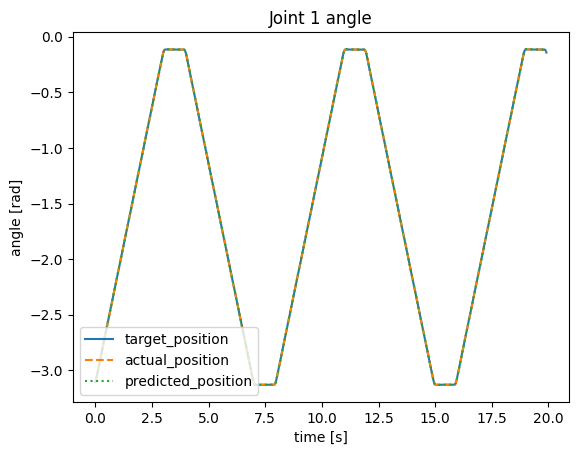

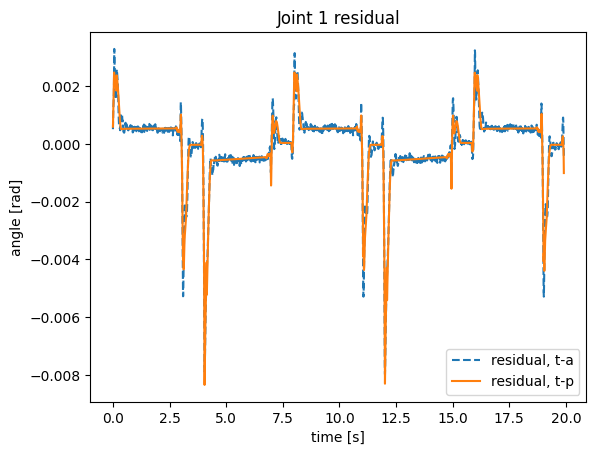

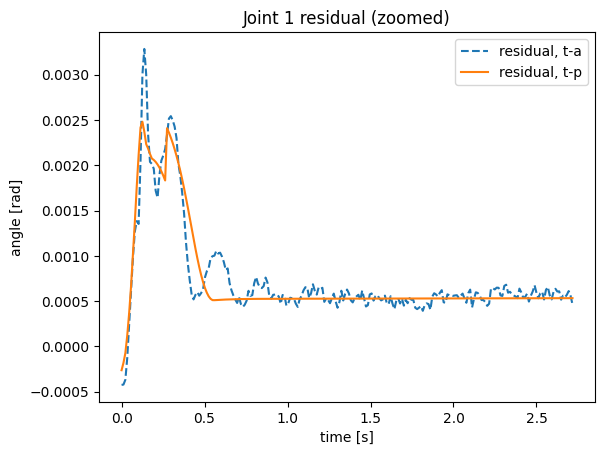

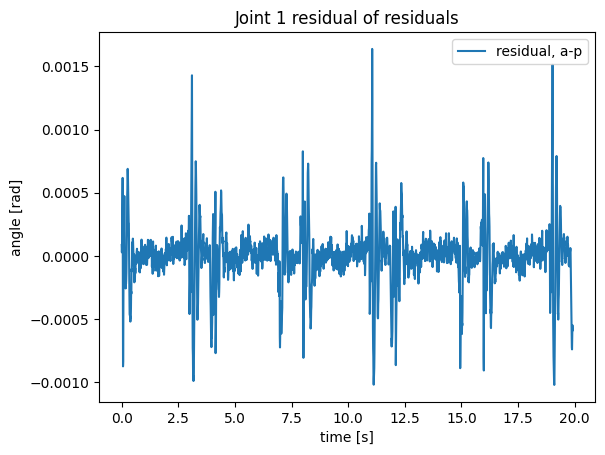

In [15]:
target_position = df["target_q1"].to_numpy()
actual_position = df["actual_q1"].to_numpy()

rmse = np.sqrt(np.mean((actual_position[:5*run_size] - predicted_position)**2))
print(rmse)

indices = [1, 2, 4, 52, 65, 77, 177]

for i in indices:
    print(f"X{i} -> {X.columns[i]}")

t = np.linspace(0,df["t"].to_numpy()[run_size],run_size)
t_zoom = np.linspace(0,df["t"].to_numpy()[run_size_zoom],run_size_zoom)

# Plotting
plt.figure()
plt.plot(t, target_position[(n)*run_size:(n+1)*run_size], label = "target_position")
plt.plot(t, actual_position[(n)*run_size:(n+1)*run_size], linestyle = '--', label = "actual_position")
plt.plot(t, predicted_position[(n)*run_size:(n+1)*run_size], linestyle = ':', label = "predicted_position")
plt.title("Joint 1 angle")
plt.xlabel("time [s]")
plt.ylabel("angle [rad]")
plt.legend()

plt.figure()
plt.plot(t, (target_position[(n)*run_size:(n+1)*run_size] - actual_position[(n)*run_size:(n+1)*run_size]), linestyle = "--", label = "residual, t-a")
plt.plot(t, (target_position[(n)*run_size:(n+1)*run_size] - predicted_position[(n)*run_size:(n+1)*run_size]), label = "residual, t-p")
plt.title("Joint 1 residual")
plt.xlabel("time [s]")
plt.ylabel("angle [rad]")
plt.legend()

plt.figure()
plt.plot(t_zoom, (target_position[(n)*run_size_zoom:(n+1)*run_size_zoom] - actual_position[(n)*run_size_zoom:(n+1)*run_size_zoom]), linestyle = "--", label = "residual, t-a")
plt.plot(t_zoom, (target_position[(n)*run_size_zoom:(n+1)*run_size_zoom] - predicted_position[(n)*run_size_zoom:(n+1)*run_size_zoom]), label = "residual, t-p")
plt.title("Joint 1 residual (zoomed)")
plt.xlabel("time [s]")
plt.ylabel("angle [rad]")
plt.legend()

plt.figure()
plt.plot(t, (actual_position[(n)*run_size:(n+1)*run_size] - predicted_position[(n)*run_size:(n+1)*run_size]), label = "residual, a-p")
plt.title("Joint 1 residual of residuals")
plt.xlabel("time [s]")
plt.ylabel("angle [rad]")
plt.legend()

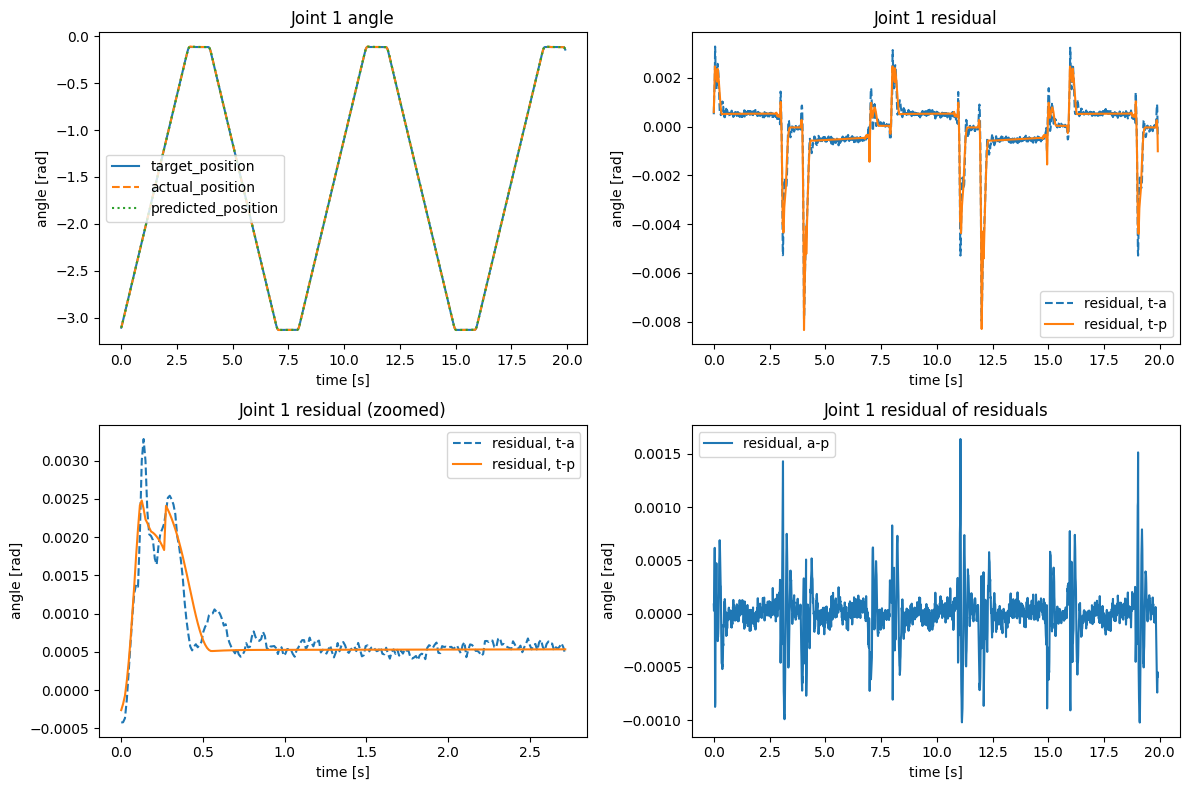

In [16]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

# 1. Joint angle
axs[0].plot(t, target_position[n*run_size:(n+1)*run_size], label="target_position")
axs[0].plot(t, actual_position[n*run_size:(n+1)*run_size],
            linestyle="--", label="actual_position")
axs[0].plot(t, predicted_position[n*run_size:(n+1)*run_size],
            linestyle=":", label="predicted_position")
axs[0].set_title("Joint 1 angle")
axs[0].set_xlabel("time [s]")
axs[0].set_ylabel("angle [rad]")
axs[0].legend()

# 2. Residual (target - actual / predicted)
axs[1].plot(
    t,
    target_position[n*run_size:(n+1)*run_size]
    - actual_position[n*run_size:(n+1)*run_size],
    linestyle="--",
    label="residual, t-a"
)
axs[1].plot(
    t,
    target_position[n*run_size:(n+1)*run_size]
    - predicted_position[n*run_size:(n+1)*run_size],
    label="residual, t-p"
)
axs[1].set_title("Joint 1 residual")
axs[1].set_xlabel("time [s]")
axs[1].set_ylabel("angle [rad]")
axs[1].legend()

# 3. Zoomed residual
axs[2].plot(
    t_zoom,
    target_position[n*run_size_zoom:(n+1)*run_size_zoom]
    - actual_position[n*run_size_zoom:(n+1)*run_size_zoom],
    linestyle="--",
    label="residual, t-a"
)
axs[2].plot(
    t_zoom,
    target_position[n*run_size_zoom:(n+1)*run_size_zoom]
    - predicted_position[n*run_size_zoom:(n+1)*run_size_zoom],
    label="residual, t-p"
)
axs[2].set_title("Joint 1 residual (zoomed)")
axs[2].set_xlabel("time [s]")
axs[2].set_ylabel("angle [rad]")
axs[2].legend()

# 4. Residual of residuals
axs[3].plot(
    t,
    actual_position[n*run_size:(n+1)*run_size]
    - predicted_position[n*run_size:(n+1)*run_size],
    label="residual, a-p"
)
axs[3].set_title("Joint 1 residual of residuals")
axs[3].set_xlabel("time [s]")
axs[3].set_ylabel("angle [rad]")
axs[3].legend()

plt.tight_layout()
plt.show()

Text(0, 0.5, 'PSD')

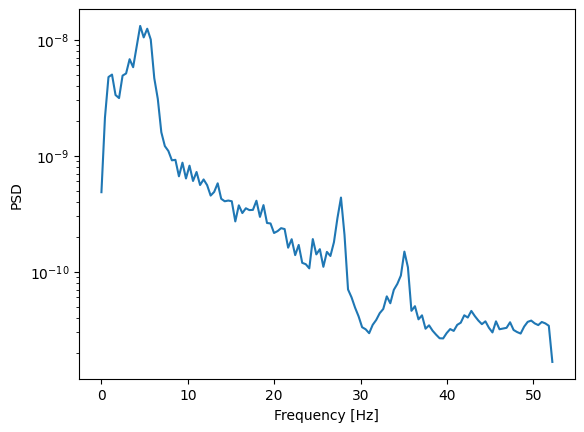

In [158]:
# Checking frequency
remaining = (
    actual_position[:(5*run_size)]
    - predicted_position
)
sampling_frequency = 1/(df["t"].to_numpy()[2] - df["t"].to_numpy()[1])

from scipy.signal import welch

f, Pxx = welch(
    remaining,
    fs=sampling_frequency
)

plt.semilogy(f, Pxx)
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")

In [142]:
n_runs = 20

best_rmse = np.inf
best_sr = None
best_model = None

for seed in range(n_runs):

    sr = SR(X, y, None, None)

    # if your wrapper exposes the seed:
    sr.reg.set_params(random_state=seed)

    sr.train()

    pred = sr.reg.predict(X)

    rmse = np.sqrt(mean_squared_error(y, pred))

    print(f"Seed {seed}: RMSE = {rmse:.8f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_sr = sr
        best_model = sr.best_model_simple

print("\nBest RMSE:", best_rmse)
print("Best model:")
print(best_model)

/home/simonmadsen/miniforge3/envs/datasim/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


R2 train:    0.9999999403953552
R2 test:     0.9999999403953552
Best model:  (0.0000005464 + (0.9999998212 * (((((-0.4844219685) * X131) - ((-0.0006963964) * X309)) / ((((-49.5862388611) * X2) + (((1.7662210464 * X173) - ((-47.7404518127) * X77)) + (201.8200378418 * X100))) + ((-3.2258155346) * X112))) - ((0.0031394495 * X305) + (((-121.2009201050) * X3) - (-9.7158498764))))))
Best model simple:  (-0.484421881885352*X131 + 0.000696396275484324*X309 + (121.200898434275*X3 - 0.00313944893866643*X305 - 9.71584759280604)*(201.8200378418*X100 - 3.2258155346*X112 + 1.7662210464*X173 - 49.5862388611*X2 + 47.7404518127*X77))/(201.8200378418*X100 - 3.2258155346*X112 + 1.7662210464*X173 - 49.5862388611*X2 + 47.7404518127*X77)
Seed 0: RMSE = 0.00026599


/home/simonmadsen/miniforge3/envs/datasim/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


R2 train:    0.9999999403953552
R2 test:     0.9999999403953552
Best model:  (0.0000115567 + (1.0000058413 * ((((((-91478602926784512.0000000000) * X77) + ((-7013088682722721792.0000000000) * X155)) + (64550691284189184.0000000000 * X76)) - ((-618330469695488.0000000000) * X84)) / (((((-772459397644288.0000000000) * X321) + (123526195445760.0000000000 * X76)) + (34269093083217920.0000000000 * X142)) - ((((-2033430120366080.0000000000) * X206) - ((-123201187217408.0000000000) * X84)) + ((-32384208601088.0000000000) * X8))))))
Best model simple:  (396037628034.824558987238561*X142 - 7013129648277643620.7600097656*X155 + 23499741872.034678096199514*X206 - 8927081520.755743646312567*X321 + 64551069771697360.0927118258*X76 - 91479137280747780.9285907745*X77 + 374254583.540193711262404*X8 + 618332657750100.2675071275*X84)/(34269093083217920.0*X142 + 2033430120366080.0*X206 - 772459397644288.0*X321 + 123526195445760.0*X76 + 32384208601088.0*X8 - 123201187217408.0*X84)
Seed 1: RMSE = 0.0002944

/home/simonmadsen/miniforge3/envs/datasim/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

R2 train:    0.9999999403953552
R2 test:     0.9999999403953552
Best model:  (0.0000014484 + (0.9999998808 * ((exp(((((-8.6674079895) * X86) + (((-264.6913146973) * X76) + ((-113.0503463745) * X94))) - ((-274.1850585938) * X78))) - ((((-94.3518905640) * X94) - ((15.4957351685 * X219) - ((-12.6467828751) * X151))) - (((-40.2653427124) * X162) + ((-5.2912468910) * X99)))) + (32.1772651672 * X3))))
Best model simple:  12.6467813676035*X151 - 40.2653379127712*X162 + 15.4957333214084*X219 + 32.17726133167*X3 + 94.3518793172546*X94 - 5.29124626028337*X99 + 0.9999998808*exp(-264.6913146973*X76 + 274.1850585938*X78 - 8.6674079895*X86 - 113.0503463745*X94) + 1.4484e-6
Seed 17: RMSE = 0.00023837


/home/simonmadsen/miniforge3/envs/datasim/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


R2 train:    0.9999999403953552
R2 test:     0.9999999403953552
Best model:  ((-0.0000011465) + (0.9999998808 * ((((((1.7378877401 * X151) - sin(((-43.8544502258) * X222))) + (0.9481068254 * X79)) + (0.9108018279 * X257)) - ((-2.6620945930) * X133)) + ((((1.9024964571 * X2) - ((7.1580023766 * X187) - 0.5212891102)) + ((-1.9626479149) * X79)) ^ (27.4666671753 * X132)))))
Best model simple:  2.66209427567832*X133 + 1.73788753294378*X151 + 0.910801719332422*X257 + 0.948106712385666*X79 + 0.9999998808*(-7.1580023766*X187 + 1.9024964571*X2 - 1.9626479149*X79 + 0.5212891102)**(27.4666671753*X132) + 0.9999998808*sin(43.8544502258*X222) - 1.1465e-6
Seed 18: RMSE = 0.00026289


/home/simonmadsen/miniforge3/envs/datasim/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


R2 train:    0.9999999403953552
R2 test:     0.9999999403953552
Best model:  ((-0.0000088763) + (0.9999984503 * (sin((((-0.4227678180) * X75) - ((-0.0147318570) * X8))) + ((((2.9978597164 * X77) + (31.7300281525 * X220)) - (1.9978455305 * X76)) - sin(((25.9866695404 * X116) + ((2.2572953701 * X77) + ((0.8809002042 * X84) - (1.8124210835 * X76)))))))))
Best model simple:  31.7299789804754*X220 - 1.99784243443878*X76 + 2.9978550706168*X77 - 0.9999984503*sin(0.422767818*X75 - 0.014731857*X8) - 0.9999984503*sin(25.9866695404*X116 - 1.8124210835*X76 + 2.2572953701*X77 + 0.8809002042*X84) - 8.8763e-6
Seed 19: RMSE = 0.00029746

Best RMSE: 0.00023836581570193412
Best model:
12.6467813676035*X151 - 40.2653379127712*X162 + 15.4957333214084*X219 + 32.17726133167*X3 + 94.3518793172546*X94 - 5.29124626028337*X99 + 0.9999998808*exp(-264.6913146973*X76 + 274.1850585938*X78 - 8.6674079895*X86 - 113.0503463745*X94) + 1.4484e-6


In [ ]:
import optuna

def objective(trial):

    max_length = trial.suggest_int("max_length", 10, 100)

    population_size = trial.suggest_int(
        "population_size",
        1000,
        100000,
        log=True
    )

    optimizer_iterations = trial.suggest_int(
        "optimizer_iterations",
        5,
        100
    )

    reg = SymbolicRegressor(
        max_length=max_length,
        population_size=population_size,
        optimizer_iterations=optimizer_iterations,
        objectives=["rmse"]
    )

    reg.fit(X, y)

    pred = reg.predict(X)

    rmse = np.sqrt(np.mean((y - pred) ** 2))

    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

[I 2026-08-20 14:57:55,038] A new study created in memory with name: no-name-c3a6ef28-1196-40a4-8ae7-070c6700dceb
[I 2026-08-20 15:02:34,315] Trial 0 finished with value: 0.0003198544547715578 and parameters: {'max_length': 83, 'population_size': 7053, 'optimizer_iterations': 65}. Best is trial 0 with value: 0.0003198544547715578.
[I 2026-08-20 15:17:31,220] Trial 1 finished with value: 0.00019276264798303143 and parameters: {'max_length': 60, 'population_size': 1320, 'optimizer_iterations': 76}. Best is trial 1 with value: 0.00019276264798303143.
[I 2026-08-20 15:21:59,372] Trial 2 finished with value: 0.00028198526576861117 and parameters: {'max_length': 69, 'population_size': 10834, 'optimizer_iterations': 12}. Best is trial 1 with value: 0.00019276264798303143.
[I 2026-08-20 15:24:33,676] Trial 3 finished with value: 0.0005817004528686689 and parameters: {'max_length': 88, 'population_size': 82203, 'optimizer_iterations': 65}. Best is trial 1 with value: 0.00019276264798303143.
[I 